# S6E2 Submission Tracker

Pulls submissions from the Kaggle API, parses local CV scores from the description
field, and plots leaderboard score vs local CV metrics.

**Needs this description format when submitting:**
```
model_name | cv_acc=0.XXXX | cv_auc=0.XXXX
```

In [15]:
import subprocess, re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COMPETITION = "playground-series-s6e2"


## Pull & Parse Submissions

In [16]:
def fetch_submissions(competition=COMPETITION):
    from io import StringIO
    result = subprocess.run(
        ["kaggle", "competitions", "submissions", "-c", competition, "--csv"],
        capture_output=True, text=True
    )
    lines = [l for l in result.stdout.splitlines() if not l.startswith("Warning:")]
    df = pd.read_csv(StringIO("\n".join(lines)))
    df.columns = df.columns.str.strip().str.lower()
    df["date"] = pd.to_datetime(df["date"], format="mixed")
    df["status"] = df["status"].str.lower().str.replace("submissionstatus.", "", regex=False)
    df = df.sort_values("date").reset_index(drop=True)  Ac
    return df

def parse_description(desc):
    if not isinstance(desc, str) or "|" not in desc:
        return {"model": desc, "cv_acc": None, "cv_auc": None}
    parts = [p.strip() for p in desc.split("|")]
    result = {"model": parts[0]}
    for part in parts[1:]:
        m = re.match(r"(cv_acc|cv_auc)=([\d.]+)", part)
        if m:
            result[m.group(1)] = float(m.group(2))
    result.setdefault("cv_acc", None)
    result.setdefault("cv_auc", None)
    return result

raw = fetch_submissions()
parsed = raw["description"].apply(parse_description).apply(pd.Series)
subs = pd.concat([raw, parsed], axis=1)
subs = subs[subs["status"] == "complete"].copy()
subs["publicscore"] = pd.to_numeric(subs["publicscore"], errors="coerce")

# ── Hard-label GBT submissions superseded by _proba versions — exclude ──────
# These submitted 0/1 labels to an AUC competition; LB scores are ~accuracy,
# not AUC. Proper _proba replacements exist for all of these.
SUPERSEDED = {
    "xgb_default.csv", "lgbm_default.csv", "catboost_default.csv",
    "catboost_es_lr005.csv", "catboost_features_a.csv",
}
subs = subs[~subs["filename"].isin(SUPERSEDED)].reset_index(drop=True)

# ── Submission type labels ───────────────────────────────────────────────────
# proba = submitted probabilities (correct for AUC metric)
# hard  = submitted 0/1 labels (LB score ≈ accuracy, not AUC — legacy)
PROBA_FILES = {f for f in subs["filename"] if "_proba" in f}
subs["sub_type"] = subs["filename"].apply(
    lambda f: "proba" if f in PROBA_FILES else "hard"
)

# ── Hardcoded CV scores for pre-convention / pre-proba submissions ───────────
pre_convention = {
    "thallium_gt4.5.csv":              {"model": "thallium_only",      "cv_acc": 0.8052, "cv_auc": 0.7990},
    "thallium_or_vessels.csv":         {"model": "thallium_or_vessels", "cv_acc": 0.8089, "cv_auc": 0.8126},
    "thallium_or_exercise_angina.csv": {"model": "thallium_or_ex_ang",  "cv_acc": 0.8094, "cv_auc": 0.8120},
    "dt_depth2.csv":   {"model": "dt_depth2",  "cv_acc": 0.8052, "cv_auc": 0.8794},
    "dt_depth3.csv":   {"model": "dt_depth3",  "cv_acc": 0.8416, "cv_auc": 0.9058},
    "dt_depth6.csv":   {"model": "dt_depth6",  "cv_acc": 0.8725, "cv_auc": 0.9395},
    "dt_depth10.csv":  {"model": "dt_depth10", "cv_acc": 0.8812, "cv_auc": 0.9488},
    "lr_default.csv":  {"model": "lr_default", "cv_acc": 0.8831, "cv_auc": 0.9505},
    "lr_l1_C0.01.csv": {"model": "lr_l1_C0.01","cv_acc": 0.8831, "cv_auc": 0.9505},
}
for fname, vals in pre_convention.items():
    mask = subs["filename"] == fname
    for col, val in vals.items():
        subs.loc[mask, col] = val
# ────────────────────────────────────────────────────────────────────────────

print(f"Total complete submissions (excl. superseded): {len(subs)}")
print()
print(subs[["date","model","sub_type","cv_auc","publicscore"]].to_string(index=False))


Total complete submissions (excl. superseded): 22

                   date                        model sub_type  cv_auc  publicscore
2026-02-22 20:40:41.127                thallium_only     hard  0.7990      0.79435
2026-02-22 21:16:07.000          thallium_or_vessels     hard  0.8126      0.80837
2026-02-22 21:16:15.927           thallium_or_ex_ang     hard  0.8120      0.80811
2026-02-22 22:02:11.000                    dt_depth2     hard  0.8794      0.79435
2026-02-22 22:02:14.823                    dt_depth3     hard  0.9058      0.83261
2026-02-22 22:02:17.803                    dt_depth6     hard  0.9395      0.86803
2026-02-22 22:02:20.777                   dt_depth10     hard  0.9488      0.87600
2026-02-22 22:09:59.953                   lr_default     hard  0.9505      0.87724
2026-02-22 22:18:23.157                  lr_l1_C0.01     hard  0.9505      0.87719
2026-02-23 01:27:30.000       catboost_default_proba    proba  0.9554      0.95356
2026-02-23 01:27:42.377           lg

## Leaderboard vs Local CV

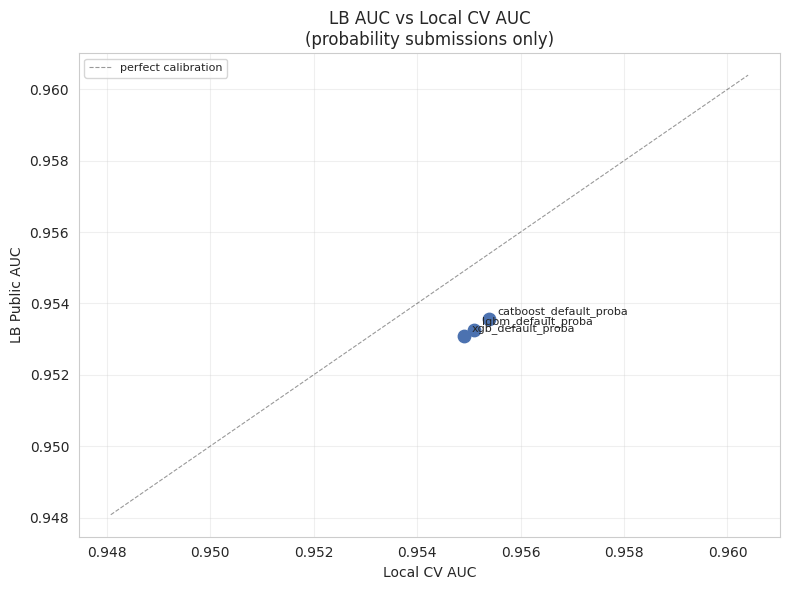

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

# Only proba submissions have comparable LB (AUC) vs CV AUC scores
proba = subs[(subs["sub_type"] == "proba") & subs["cv_auc"].notna() & subs["publicscore"].notna()]

ax.scatter(proba["cv_auc"], proba["publicscore"], zorder=3, s=80, color="#4C72B0")
for _, row in proba.iterrows():
    ax.annotate(row["model"], (row["cv_auc"], row["publicscore"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

if not proba.empty:
    lo = min(proba["cv_auc"].min(), proba["publicscore"].min()) - 0.005
    hi = max(proba["cv_auc"].max(), proba["publicscore"].max()) + 0.005
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8, alpha=0.4, label="perfect calibration")

ax.set_xlabel("Local CV AUC")
ax.set_ylabel("LB Public AUC")
ax.set_title("LB AUC vs Local CV AUC\n(probability submissions only)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## All Submissions Bar Chart

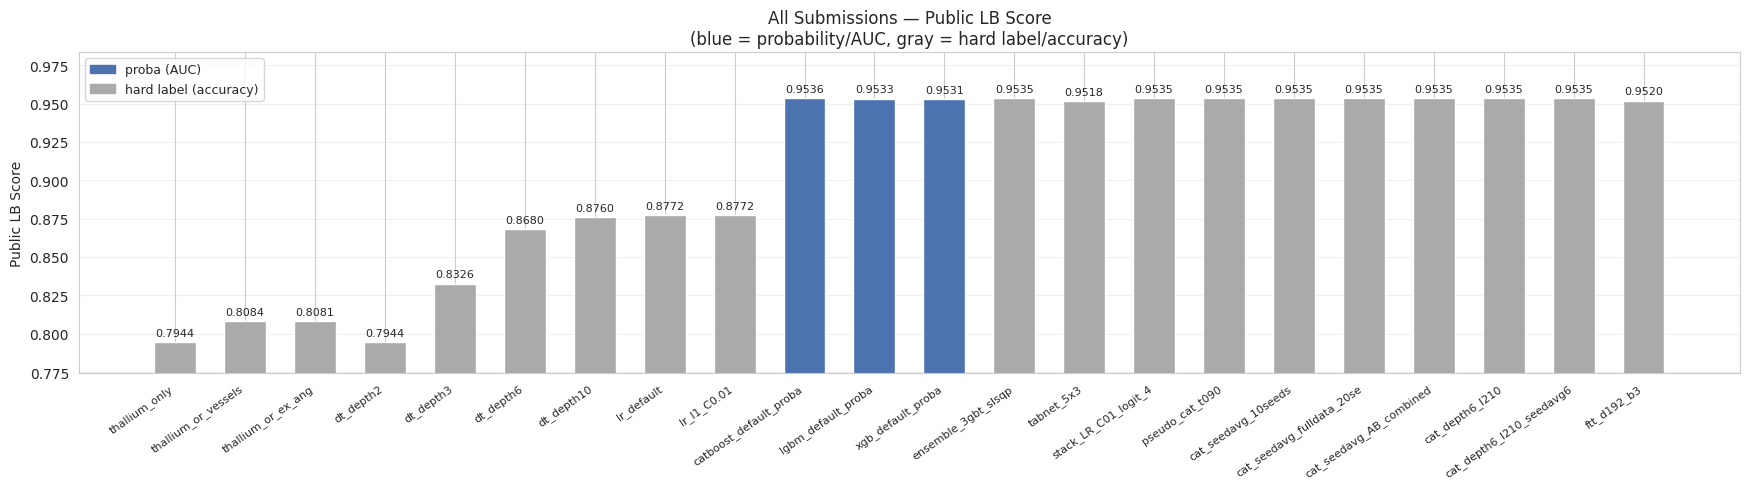

Best proba submission: catboost_default_proba (0.95356)


In [18]:
colors = subs["sub_type"].map({"proba": "#4C72B0", "hard": "#aaaaaa"})

fig, ax = plt.subplots(figsize=(max(8, len(subs) * 0.8), 5))
x = range(len(subs))
bars = ax.bar(x, subs["publicscore"], color=colors, width=0.6)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [m[:25] if isinstance(m, str) else f.split(".")[0][:25]
     for m, f in zip(subs["model"], subs["filename"])],
    rotation=35, ha="right", fontsize=8
)
ax.set_ylabel("Public LB Score")
ax.set_title("All Submissions — Public LB Score\n(blue = probability/AUC, gray = hard label/accuracy)")
ax.set_ylim(subs["publicscore"].min() - 0.02, subs["publicscore"].max() + 0.03)
ax.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#4C72B0", label="proba (AUC)"),
                   Patch(color="#aaaaaa", label="hard label (accuracy)")],
          fontsize=9)
plt.tight_layout()
plt.show()

best_proba = subs[subs["sub_type"] == "proba"]
if not best_proba.empty:
    best = best_proba.loc[best_proba["publicscore"].idxmax()]
    print(f"Best proba submission: {best['model']} ({best['publicscore']:.5f})")
